In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    silhouette_samples
)

In [3]:
df = pd.read_csv("data/Mall_Customers.csv")

print("Shape:", df.shape)

df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Remove ID column

df = df.drop(columns=["CustomerID"])

# Convert Gender to numeric

df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [7]:
print(df.shape)
print(df.dtypes)

(200, 4)
Gender                    int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [8]:
# Detect outliers using IQR

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (
    (df < (Q1 - 1.5 * IQR)) |
    (df > (Q3 + 1.5 * IQR))
)

print(
    "Rows with at least one outlier:",
    outlier_mask.any(axis=1).sum()
)

Rows with at least one outlier: 2


In [9]:
# Remove IQR outliers

df_clean = df[
    ~outlier_mask.any(axis=1)
]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (200, 4)
Cleaned shape: (198, 4)


In [10]:
# Standardize features

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_clean.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.141195,-1.425414,-1.779171,-0.435989
1,-1.141195,-1.282367,-1.779171,1.199413
2,0.876275,-1.353890,-1.739447,-1.720949
3,0.876275,-1.139319,-1.739447,1.043661
4,0.876275,-0.567131,-1.699723,-0.397051


In [11]:
print(scaled_df.mean().round(2))
print()
print(scaled_df.std().round(2))

Gender                    0.0
Age                       0.0
Annual Income (k$)        0.0
Spending Score (1-100)    0.0
dtype: float64

Gender                    1.0
Age                       1.0
Annual Income (k$)        1.0
Spending Score (1-100)    1.0
dtype: float64


c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

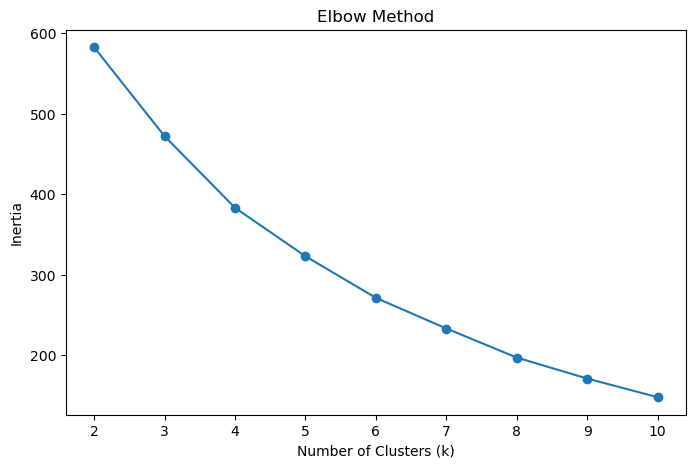

In [12]:
# Elbow Method

inertia_values = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

In [13]:
results = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        scaled_df
    )

    silhouette = silhouette_score(
        scaled_df,
        labels
    )

    davies = davies_bouldin_score(
        scaled_df,
        labels
    )

    results.append(
        [k, silhouette, davies]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "k",
        "Silhouette Score",
        "Davies-Bouldin Score"
    ]
)

results_df

c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,k,Silhouette Score,Davies-Bouldin Score
0,2,0.250900,1.616063
1,3,0.258237,1.370182
2,4,0.300561,1.300654
3,5,0.317418,1.150495
4,6,0.334791,1.014756
5,7,0.359751,0.974843
6,8,0.390705,0.940724
7,9,0.404358,0.877237
8,10,0.424714,0.827332


In [14]:
# Final K-Means model

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df["KMeans_Cluster"] = kmeans_labels

scaled_df["KMeans_Cluster"].value_counts().sort_index()

c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans_Cluster
0    42
1    56
2    28
3    32
4    40
Name: count, dtype: int64

In [15]:
scaled_df["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    56
0    42
4    40
3    32
2    28
Name: count, dtype: int64

In [16]:
cluster_summary = (
    scaled_df
    .groupby("KMeans_Cluster")
    .mean()
)

cluster_summary

,Gender,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,,
0,0.876275,0.730510,-0.534474,-0.411885
1,0.876275,-0.753603,0.025451,0.700171
2,-1.141195,1.307807,-0.516503,-0.447115
3,-0.258552,0.148104,1.102089,-1.296279
4,-1.141195,-0.745940,0.005447,0.802244


### K-Means Cluster Interpretation

The K-Means model identified five customer segments. Some clusters consisted of younger customers with higher spending scores, while others represented older customers with lower spending behavior. One cluster contained customers with relatively high income but low spending scores, suggesting an opportunity for targeted marketing efforts. Another cluster represented high-spending customers who may be considered the most valuable segment for the business.

Overall, the mall customer dataset produced more diverse customer segments than the credit card dataset, which primarily separated customers into two major groups.

In [17]:
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

hierarchical_labels = hierarchical.fit_predict(
    scaled_df.drop(columns=["KMeans_Cluster"])
)

scaled_df["Hierarchical_Cluster"] = hierarchical_labels

scaled_df["Hierarchical_Cluster"].value_counts().sort_index()

Hierarchical_Cluster
0    59
1    38
2    32
3    38
4    31
Name: count, dtype: int64

In [18]:
hierarchical_silhouette = silhouette_score(
    scaled_df.drop(
        columns=["KMeans_Cluster", "Hierarchical_Cluster"]
    ),
    hierarchical_labels
)

hierarchical_davies = davies_bouldin_score(
    scaled_df.drop(
        columns=["KMeans_Cluster", "Hierarchical_Cluster"]
    ),
    hierarchical_labels
)

print("Silhouette Score:", hierarchical_silhouette)
print("Davies-Bouldin Score:", hierarchical_davies)

Silhouette Score: 0.287234370305794
Davies-Bouldin Score: 1.221691402810367


K-Means produced slightly better-defined customer segments than Hierarchical Clustering. The higher silhouette score and lower Davies-Bouldin score indicate that the K-Means clusters were more compact and better separated

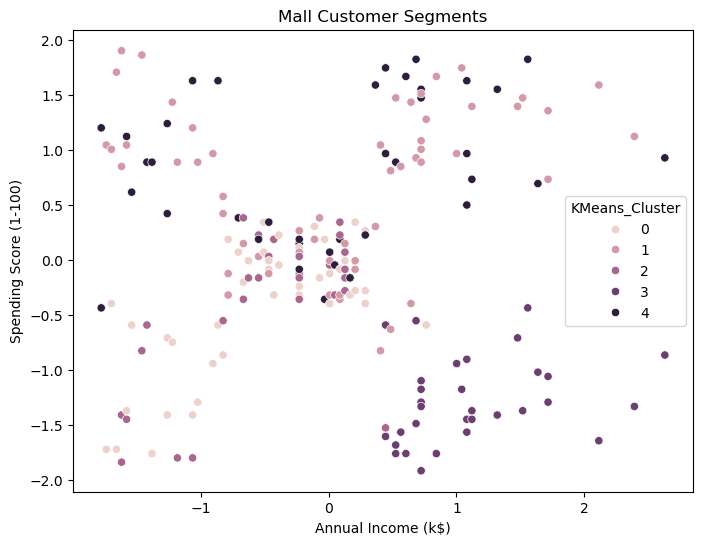

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=scaled_df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="KMeans_Cluster"
)

plt.title("Mall Customer Segments")
plt.show()

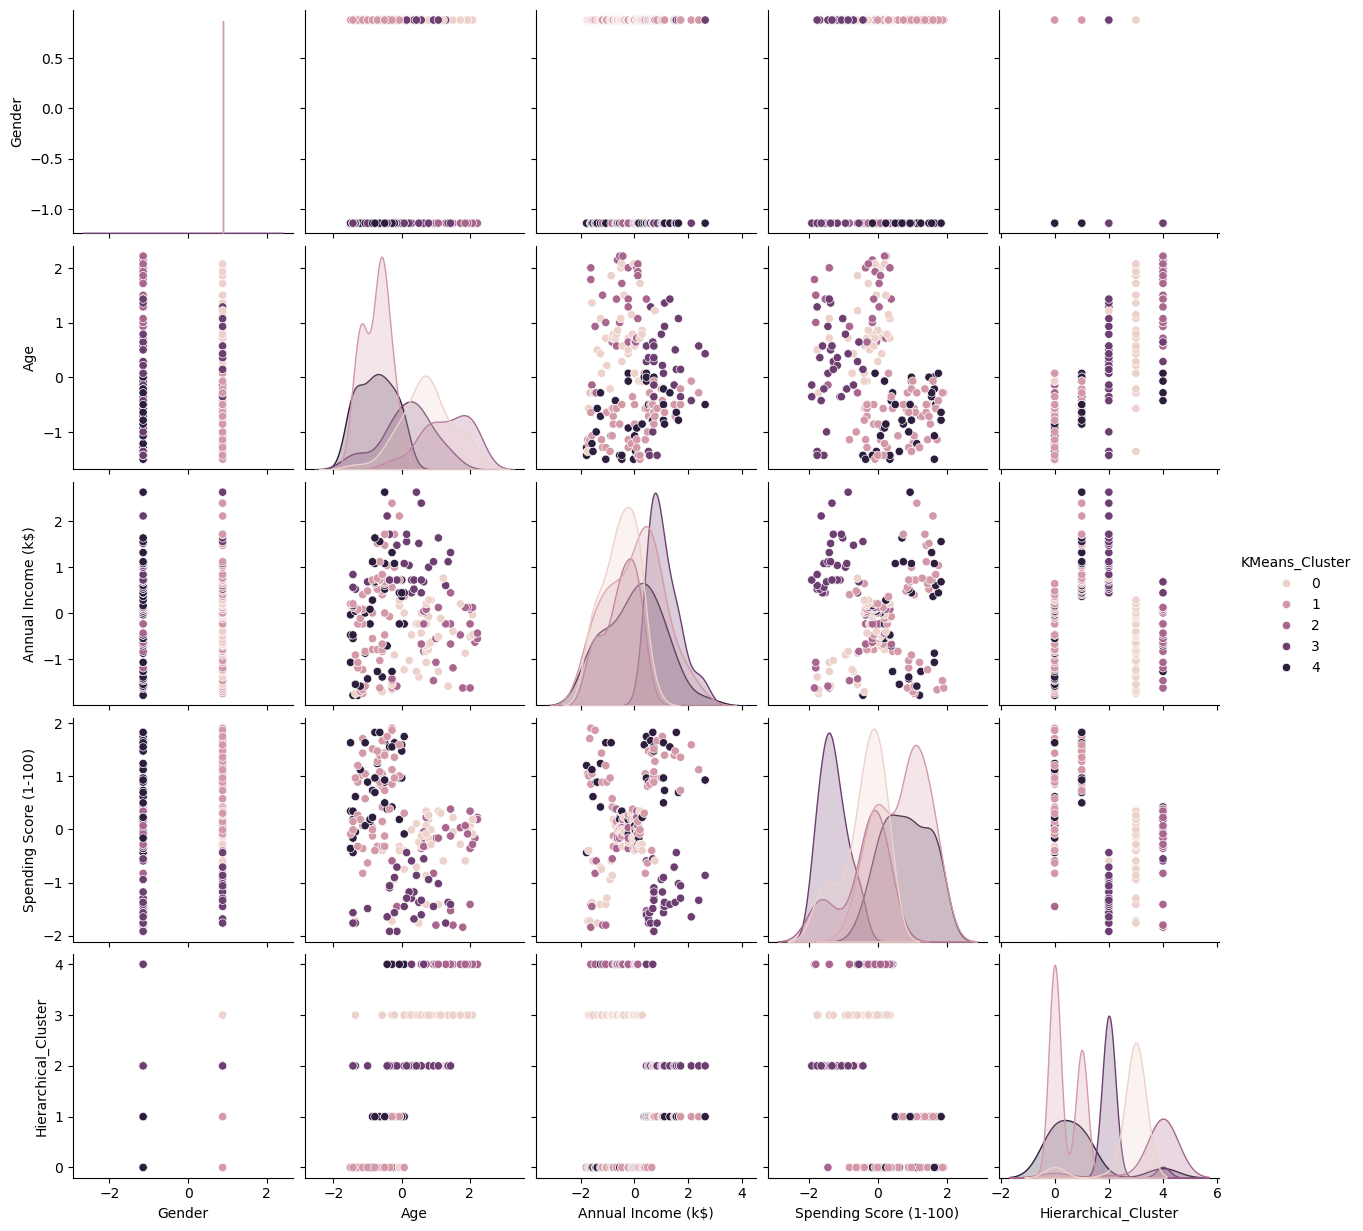

In [20]:
sns.pairplot(
    scaled_df,
    hue="KMeans_Cluster"
)

plt.show()

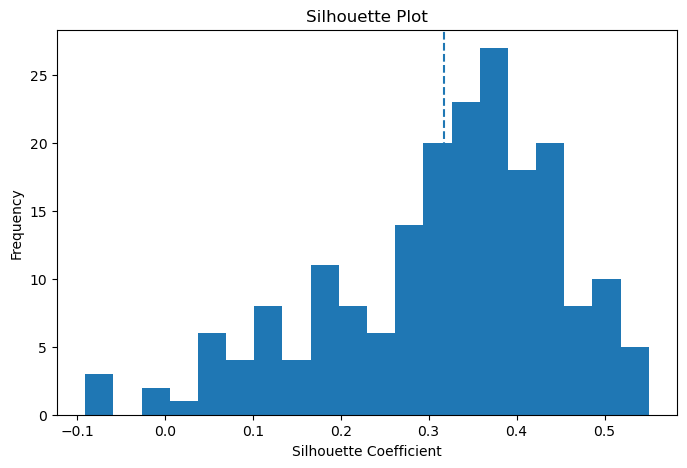

In [21]:
sample_silhouette_values = silhouette_samples(
    scaled_df.drop(
        columns=["KMeans_Cluster", "Hierarchical_Cluster"]
    ),
    kmeans_labels
)

plt.figure(figsize=(8,5))

plt.hist(
    sample_silhouette_values,
    bins=20
)

plt.axvline(
    sample_silhouette_values.mean(),
    linestyle="--"
)

plt.title("Silhouette Plot")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Frequency")

plt.show()

## Discussion

### How well did K-Means and Hierarchical Clustering segment the data?

K-Means segmented the mall customers better than Hierarchical Clustering. With 5 clusters, K-Means had a silhouette score of about 0.317 and a Davies-Bouldin score of about 1.150. Hierarchical Clustering had a lower silhouette score of about 0.287 and a higher Davies-Bouldin score of about 1.222. This suggests that K-Means created slightly cleaner customer groups.

### What challenges did you encounter in feature scaling and outlier detection?

The mall customers dataset was cleaner than the credit card dataset because it had only 200 rows, no missing values, and only 2 outlier rows removed by the IQR method. The main preprocessing challenge was converting Gender from text into numbers so the clustering algorithms could use it. Scaling was still important because age, income, and spending score use different ranges.

### How do silhouette and Davies-Bouldin scores help in cluster evaluation?

Silhouette score and Davies-Bouldin score helped compare different cluster counts and models. A higher silhouette score means the clusters are more separated, while a lower Davies-Bouldin score means the clusters are more compact and distinct. In this dataset, the scores kept improving as k increased, but I chose 5 clusters because it gave useful customer segments without making the analysis too complicated.

### Compare and contrast results from the primary dataset and secondary dataset

The credit card dataset formed two clear customer groups, while the mall customers dataset produced five more detailed customer segments. The credit card dataset had stronger evaluation scores, which means the clusters were more clearly separated. The mall customers dataset was easier to clean, but the clusters were less clearly separated because customer shopping behavior was more mixed. Overall, both datasets showed how clustering can be used to group people based on behavior, but the credit card dataset had cleaner separation between groups.